# BankRisk Compass: Credit Default Risk Modeling

This notebook builds a credit-risk model that estimates the probability that a loan applicant will default. The goal is not only to maximize model scores, but to make the decision logic useful for a bank: missed defaults are expensive, while unnecessary rejections can hurt revenue and customer experience.

The productionized pieces of this project live outside the notebook:

- `src/train_model.py` contains the leakage-safe training pipeline.
- `models/credit_risk_model.pkl` stores the final model bundle.
- `reports/` stores model metrics, charts, threshold analysis, and feature importance.
- `app/views.py` and `app/templates/` provide the Django dashboard.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "credit_risk.csv"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODEL_PATH = PROJECT_ROOT / "models" / "credit_risk_model.pkl"

sns.set_theme(style="whitegrid", palette="Set2")

## 1. Load the Dataset

Each row represents a loan applicant. The target variable is `loan_status`, where `1` means default and `0` means non-default.

In [2]:
data = pd.read_csv(DATA_PATH)
print(data.shape)
data.head()

(32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [4]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_age,32581.0,NaN,NaN,NaN,27.7346,6.348078,20.0,23.0,26.0,30.0,144.0
person_income,32581.0,NaN,NaN,NaN,66074.84847,61983.119168,4000.0,38500.0,55000.0,79200.0,6000000.0
person_home_ownership,32581,4,RENT,16446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,31686.0,NaN,NaN,NaN,4.789686,4.14263,0.0,2.0,4.0,7.0,123.0
loan_intent,32581,6,EDUCATION,6453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,32581,7,A,10777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,32581.0,NaN,NaN,NaN,9589.371106,6322.086646,500.0,5000.0,8000.0,12200.0,35000.0
loan_int_rate,29465.0,NaN,NaN,NaN,11.011695,3.240459,5.42,7.9,10.99,13.47,23.22
loan_status,32581.0,NaN,NaN,NaN,0.218164,0.413006,0.0,0.0,0.0,0.0,1.0
loan_percent_income,32581.0,NaN,NaN,NaN,0.170203,0.106782,0.0,0.09,0.15,0.23,0.83


## 2. Data Quality Checks

The model code handles missing values inside the scikit-learn pipeline. That matters because imputing before the train/test split would leak information from the test set into training.

In [5]:
quality = pd.DataFrame({
    "missing_values": data.isna().sum(),
    "missing_rate": data.isna().mean(),
    "unique_values": data.nunique()
}).sort_values("missing_values", ascending=False)
quality

,missing_values,missing_rate,unique_values
loan_int_rate,3116,0.095639,348
person_emp_length,895,0.027470,36
person_income,0,0.000000,4295
person_age,0,0.000000,58
person_home_ownership,0,0.000000,4
loan_intent,0,0.000000,6
loan_grade,0,0.000000,7
loan_amnt,0,0.000000,753
loan_status,0,0.000000,2
loan_percent_income,0,0.000000,77


In [6]:
class_balance = data["loan_status"].value_counts(normalize=True).rename({0: "non_default", 1: "default"})
class_balance

loan_status
non_default    0.781836
default        0.218164
Name: proportion, dtype: float64

Interpretation: the data is imbalanced. Most borrowers do not default, so accuracy alone is not enough. Recall, precision, F1-score, ROC-AUC, and business thresholding are more informative.

## 3. Exploratory Data Analysis

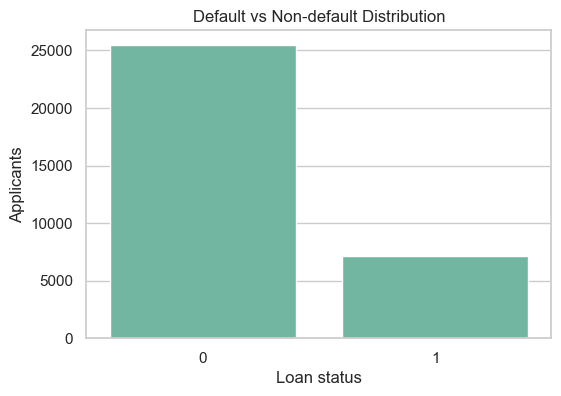

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="loan_status")
plt.title("Default vs Non-default Distribution")
plt.xlabel("Loan status")
plt.ylabel("Applicants")
plt.show()

The target distribution confirms the class imbalance: non-defaults dominate the dataset.

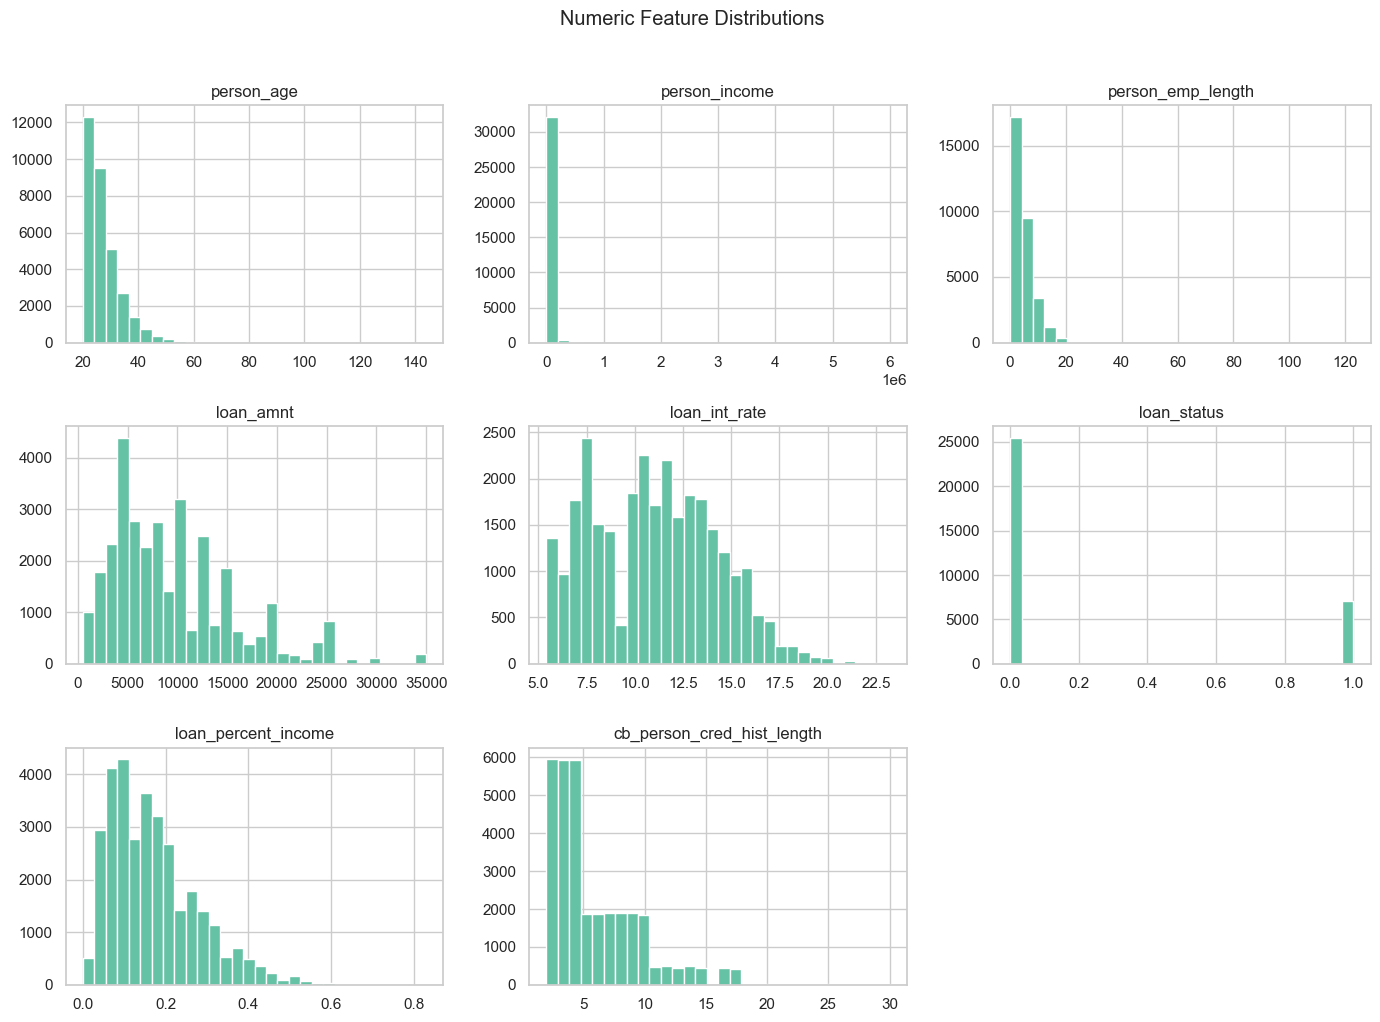

In [ ]:
numeric_cols = data.select_dtypes(include="number").columns.tolist()
data[numeric_cols].hist(figsize=(14, 10), bins=20)
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()


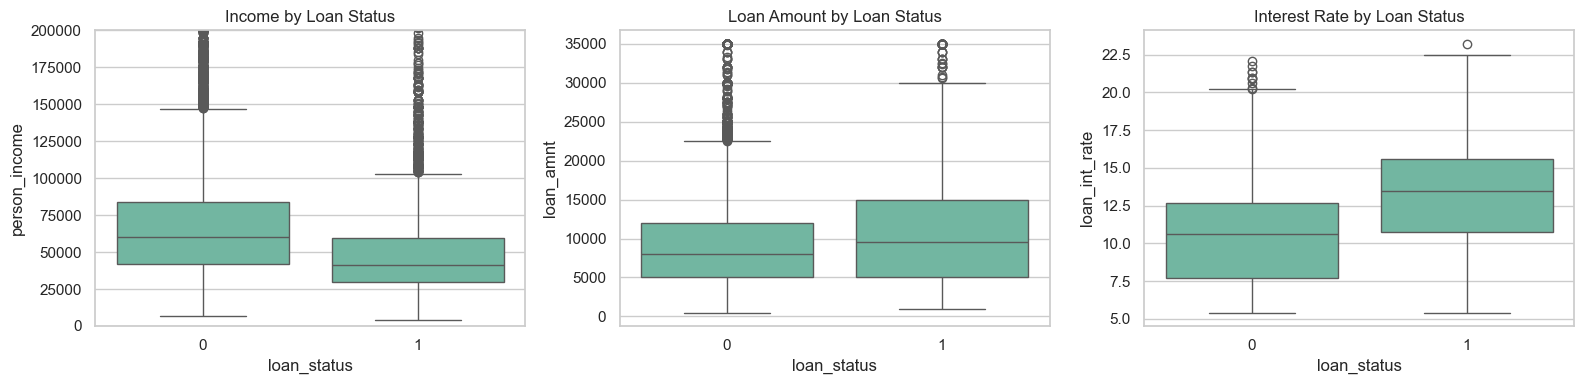

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=data, x="loan_status", y="person_income", ax=axes[0])
axes[0].set_ylim(0, 200000)
axes[0].set_title("Income by Loan Status")

sns.boxplot(data=data, x="loan_status", y="loan_amnt", ax=axes[1])
axes[1].set_title("Loan Amount by Loan Status")

sns.boxplot(data=data, x="loan_status", y="loan_int_rate", ax=axes[2])
axes[2].set_title("Interest Rate by Loan Status")

plt.tight_layout()
plt.show()

Defaulted loans tend to show higher interest rates and heavier loan burden relative to income. Income has strong outliers, so the chart is capped to keep the central pattern visible.

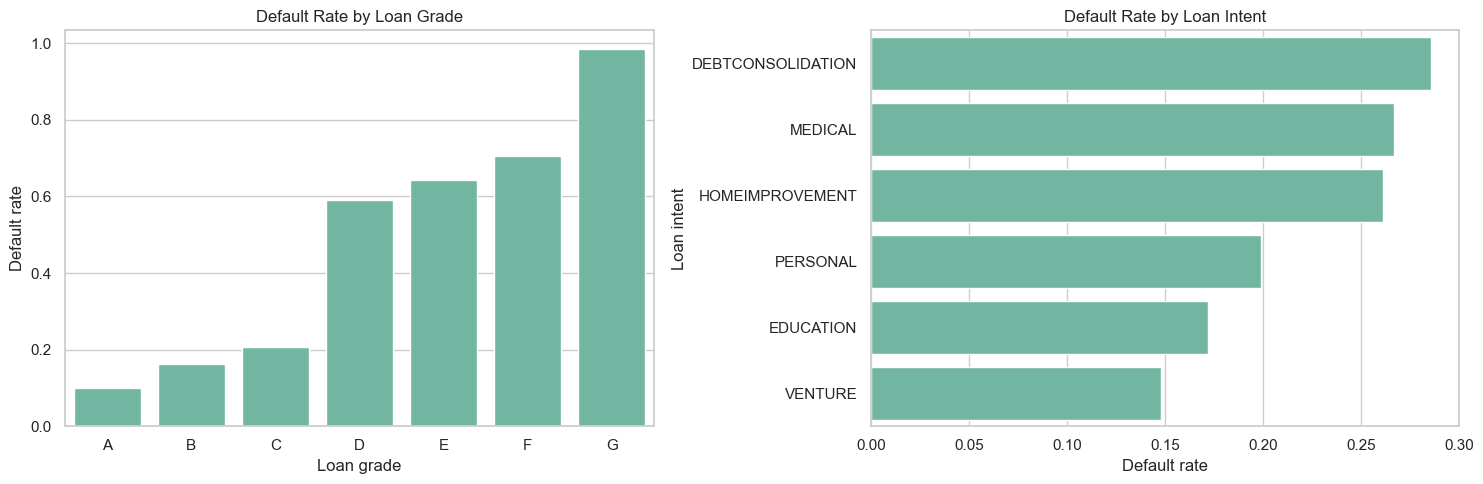

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

grade_default = data.groupby("loan_grade")["loan_status"].mean().sort_index()
sns.barplot(x=grade_default.index, y=grade_default.values, ax=axes[0])
axes[0].set_title("Default Rate by Loan Grade")
axes[0].set_ylabel("Default rate")
axes[0].set_xlabel("Loan grade")

intent_default = data.groupby("loan_intent")["loan_status"].mean().sort_values(ascending=False)
sns.barplot(x=intent_default.values, y=intent_default.index, ax=axes[1])
axes[1].set_title("Default Rate by Loan Intent")
axes[1].set_xlabel("Default rate")
axes[1].set_ylabel("Loan intent")

plt.tight_layout()
plt.show()

Loan grade is one of the clearest risk separators. Loan intent also contains useful signal, especially when combined with borrower income and loan burden.

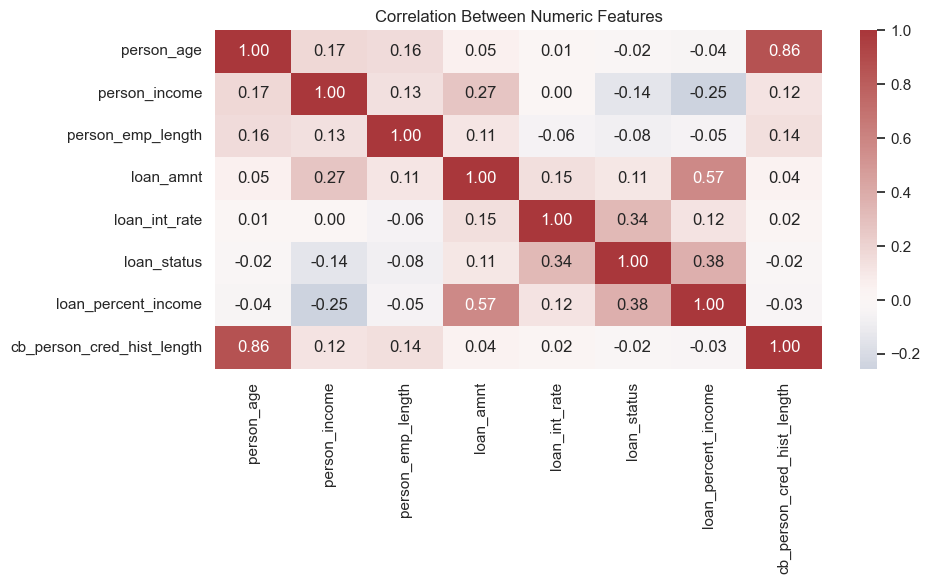

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(data[numeric_cols].corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation Between Numeric Features")
plt.tight_layout()
plt.show()

## 4. Leakage-Safe Modeling Workflow

Preprocessing is fitted only on the training split using `ColumnTransformer` and `Pipeline`:

- numeric features: median imputation and scaling
- categorical features: most-frequent imputation and one-hot encoding
- model: calibrated champion selected after threshold-aware comparison of Logistic Regression, Random Forest, and Gradient Boosting

In [12]:
from src.train_model import (
    CATEGORICAL_FEATURES,
    FEATURES,
    NUMERIC_FEATURES,
    TARGET,
    build_preprocessor,
)

print("Numeric features:", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)
build_preprocessor()

Numeric features: ['person_income', 'person_emp_length', 'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length']
Categorical features: ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']


,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 5. Train or Load Project Artifacts

The training script uses separate model-selection, calibration, threshold-selection, and final-test partitions. It compares calibrated candidates under their selected policies, saves the champion, and writes governance reports. If artifacts already exist, this cell simply reads them.

In [13]:
from src.train_model import train_and_save

if not MODEL_PATH.exists():
    train_and_save(quick=True)

model_comparison = pd.read_csv(REPORTS_DIR / "model_comparison.csv")
final_metrics = pd.read_csv(REPORTS_DIR / "final_model_metrics.csv")
threshold_analysis = pd.read_csv(REPORTS_DIR / "threshold_analysis.csv")
permutation_importance = pd.read_csv(REPORTS_DIR / "permutation_importance.csv")

model_comparison

,model,accuracy,precision,recall,f1_score,roc_auc,average_precision,brier_score,decision_threshold,business_cost,evaluation_split
0,Gradient Boosting,0.825299,0.576408,0.758377,0.654989,0.890417,0.797094,0.087436,0.21,1001,selection_after_calibration_and_thresholding
1,Random Forest,0.816815,0.560209,0.754850,0.643125,0.878809,0.784285,0.091020,0.19,1031,selection_after_calibration_and_thresholding
2,Logistic Regression,0.749325,0.454042,0.723104,0.557823,0.826421,0.628683,0.121689,0.22,1278,selection_after_calibration_and_thresholding


Gradient Boosting has the lowest selection-set business cost and the strongest calibrated F1-score and ROC-AUC, so it is promoted as the champion. The final test set remains untouched during this choice.

In [14]:
model_comparison.set_index("model")[["accuracy", "precision", "recall", "f1_score", "roc_auc"]].plot(
    kind="bar",
    figsize=(11, 5),
    ylim=(0, 1),
    rot=0,
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("")
plt.tight_layout()
plt.show()

C:\Users\thinkpad\AppData\Local\Temp\ipykernel_23452\630739277.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 6. Business-Focused Threshold Tuning

A normal `0.50` threshold is not always the best business decision. In this project, a false negative is treated as 5x more costly than a false positive:

- False negative: a risky borrower is approved.
- False positive: a safer borrower is rejected or sent to manual review.

In [15]:
final_metrics

,model,evaluation_split,decision_threshold,accuracy,precision,recall,f1_score,roc_auc,average_precision,brier_score
0,Gradient Boosting,final_test,0.50,0.883868,0.880000,0.543018,0.671609,0.881284,0.791345,0.088549
1,Gradient Boosting,final_test,0.21,0.827730,0.581749,0.755289,0.657257,0.881284,0.791345,0.088549


In [16]:
selected_threshold = final_metrics.loc[final_metrics["decision_threshold"] != 0.5, "decision_threshold"].iloc[0]

plt.figure(figsize=(11, 5))
plt.plot(threshold_analysis["threshold"], threshold_analysis["precision"], label="Precision")
plt.plot(threshold_analysis["threshold"], threshold_analysis["recall"], label="Recall")
plt.plot(threshold_analysis["threshold"], threshold_analysis["f1_score"], label="F1-score")
plt.axvline(selected_threshold, color="black", linestyle="--", label=f"Business threshold = {selected_threshold:.2f}")
plt.title("Threshold Tradeoff")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\thinkpad\AppData\Local\Temp\ipykernel_23452\2092410718.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


The business threshold increases default recall by accepting more manual review or rejection cases. This is more realistic for credit risk than optimizing accuracy alone.

## 7. Model Explanation

Permutation importance is used to explain which original applicant features matter most to the final model. This avoids relying only on one-hot encoded internal feature names.

In [17]:
top_importance = permutation_importance.head(10).sort_values("importance_mean")
plt.figure(figsize=(10, 6))
plt.barh(top_importance["feature"], top_importance["importance_mean"])
plt.title("Top Credit Risk Drivers")
plt.xlabel("Permutation importance")
plt.tight_layout()
plt.show()

permutation_importance.head(10)

C:\Users\thinkpad\AppData\Local\Temp\ipykernel_23452\2512161989.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,feature,importance_mean,importance_std
0,loan_percent_income,0.306821,0.014577
1,person_home_ownership,0.175360,0.011415
2,person_income,0.148781,0.007491
3,loan_intent,0.049392,0.009031
4,cb_person_default_on_file,0.025079,0.003751
5,person_emp_length,0.006306,0.003799
6,cb_person_cred_hist_length,0.000643,0.001755
7,loan_amnt,-0.003710,0.001916


## 8. Final Report

**Best model:** Gradient Boosting

**Default threshold results:**

- Accuracy: 88.0%
- F1-score: 0.672
- Recall for defaults: 0.543
- ROC-AUC: 0.881

**Business threshold results:**

- Threshold-selection result: 0.21
- Accuracy: 82.8%
- F1-score: 0.657
- Recall for defaults: 0.755

**Business interpretation:** the calibrated Gradient Boosting model uses application-time features and excludes lender-assigned grade, interest rate, and age from scoring. Age remains available only for input checks and subgroup monitoring. Model selection, calibration, and threshold choice use separate data partitions before one final evaluation on the untouched test set. The lower threshold catches more potential defaults while increasing the number of applicants sent to human review.

The saved model is available at `models/credit_risk_model.pkl`, and the Django dashboard runs with `python manage.py runserver`.